**Loading dataset**

In [3]:
import pandas as pd

df = pd.read_excel("Student Dropout Prediction - Dataset.xlsx")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Checking Missing Values**

In [4]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
display(missing_values)

print("Total Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


Total Missing Values: 0


**Checking Duplicate Records**

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


**Checking DataTypes**

In [6]:
print("Data Types:")
print(df.dtypes)

Data Types:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Ge

**Checking Target Values**

In [7]:
print("Target Values:")
print(df["Target"].value_counts())

Target Values:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [8]:
print("Unique Target Values:")
print(df["Target"].unique())

Unique Target Values:
['Dropout' 'Graduate' 'Enrolled']


**Converting the target into Dropout / Not Dropout**

In [9]:
df["Dropout"] = df["Target"].apply(
    lambda x: 1 if x == "Dropout" else 0
)

print(df["Dropout"].value_counts())

Dropout
0    3003
1    1421
Name: count, dtype: int64


In [10]:
df = df.drop(columns=["Target"])

In [11]:
print("Final Dataset Shape:", df.shape)
display(df.head())

Final Dataset Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Dropout
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


**Separtaing Features and Target**

In [12]:
X = df.drop(columns=["Dropout"])
y = df["Dropout"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (4424, 36)
Target Shape: (4424,)


**Checking the final dataset**

In [13]:
print("Final Dataset Information:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Dropout"].value_counts())

Final Dataset Information:
Rows: 4424
Columns: 37
Missing Values: 0
Duplicate Rows: 0

Target Distribution:
Dropout
0    3003
1    1421
Name: count, dtype: int64


**Statistical summary**

In [14]:
print("Statistical Summary:")

display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Dropout Distribution**

Dropout Distribution:
Dropout
0    3003
1    1421
Name: count, dtype: int64


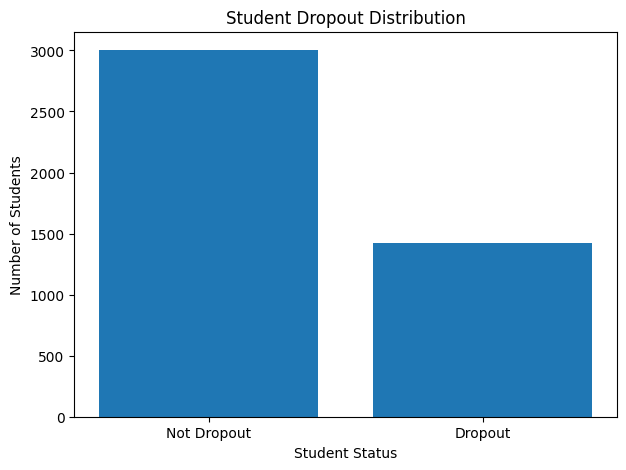

In [15]:
import matplotlib.pyplot as plt

dropout_counts = df["Dropout"].value_counts().sort_index()

print("Dropout Distribution:")
print(dropout_counts)

plt.figure(figsize=(7,5))

plt.bar(
    ["Not Dropout", "Dropout"],
    dropout_counts.values
)

plt.title("Student Dropout Distribution")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")

plt.show()

**Academic Performance - 1st & 2nd  Semester Grades**

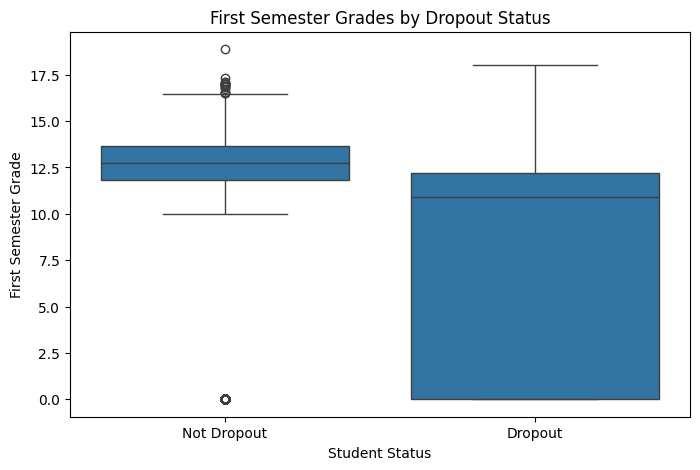

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout",
    y="Curricular units 1st sem (grade)"
)

plt.xticks(
    [0, 1],
    ["Not Dropout", "Dropout"]
)

plt.title("First Semester Grades by Dropout Status")
plt.xlabel("Student Status")
plt.ylabel("First Semester Grade")

plt.show()

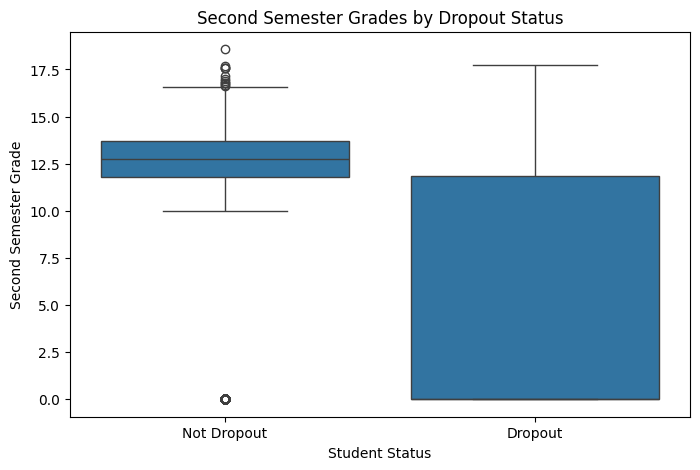

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout",
    y="Curricular units 2nd sem (grade)"
)

plt.xticks(
    [0, 1],
    ["Not Dropout", "Dropout"]
)

plt.title("Second Semester Grades by Dropout Status")
plt.xlabel("Student Status")
plt.ylabel("Second Semester Grade")

plt.show()

**Approved courses vs dropout**

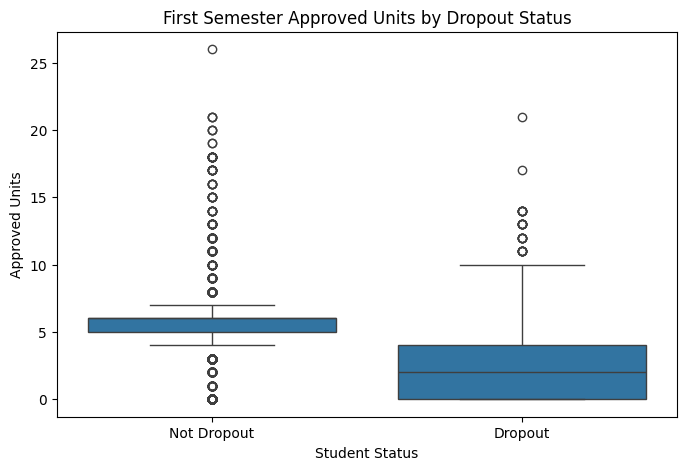

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout",
    y="Curricular units 1st sem (approved)"
)

plt.xticks(
    [0, 1],
    ["Not Dropout", "Dropout"]
)

plt.title("First Semester Approved Units by Dropout Status")
plt.xlabel("Student Status")
plt.ylabel("Approved Units")

plt.show()

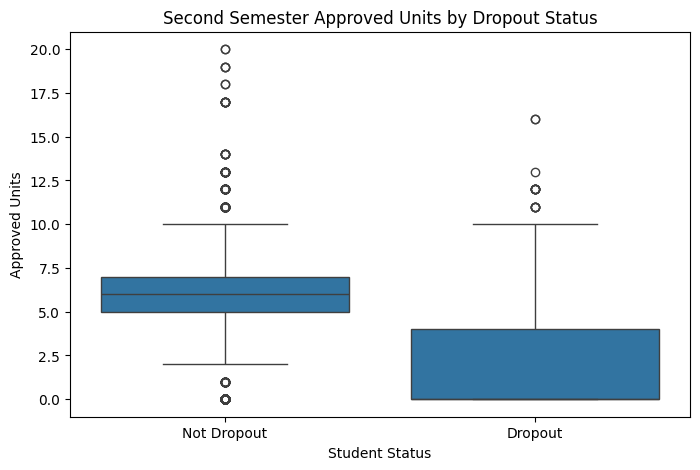

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout",
    y="Curricular units 2nd sem (approved)"
)

plt.xticks(
    [0, 1],
    ["Not Dropout", "Dropout"]
)

plt.title("Second Semester Approved Units by Dropout Status")
plt.xlabel("Student Status")
plt.ylabel("Approved Units")

plt.show()

**Comparing academic averages**

In [20]:
academic_features = [
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

academic_summary = df.groupby("Dropout")[academic_features].mean()

academic_summary.index = ["Not Dropout", "Dropout"]

display(academic_summary)

,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade)
Not Dropout,5.726274,12.242187,5.616717,12.279544
Dropout,2.551724,7.256656,1.940183,5.899339


**Correlation with Dropout**

In [21]:
correlations = df.corr(numeric_only=True)["Dropout"].sort_values(
    ascending=False
)

print("Correlation with Dropout:")

display(correlations)

Correlation with Dropout:


,Dropout
Dropout,1.000000
Age at enrollment,0.254215
Debtor,0.229407
Gender,0.203983
Application mode,0.198458
Marital status,0.093712
Curricular units 2nd sem (without evaluations),0.079901
Mother's qualification,0.064958
Curricular units 1st sem (without evaluations),0.054230
Previous qualification,0.049379


**Visualizing Stronger Relationships**

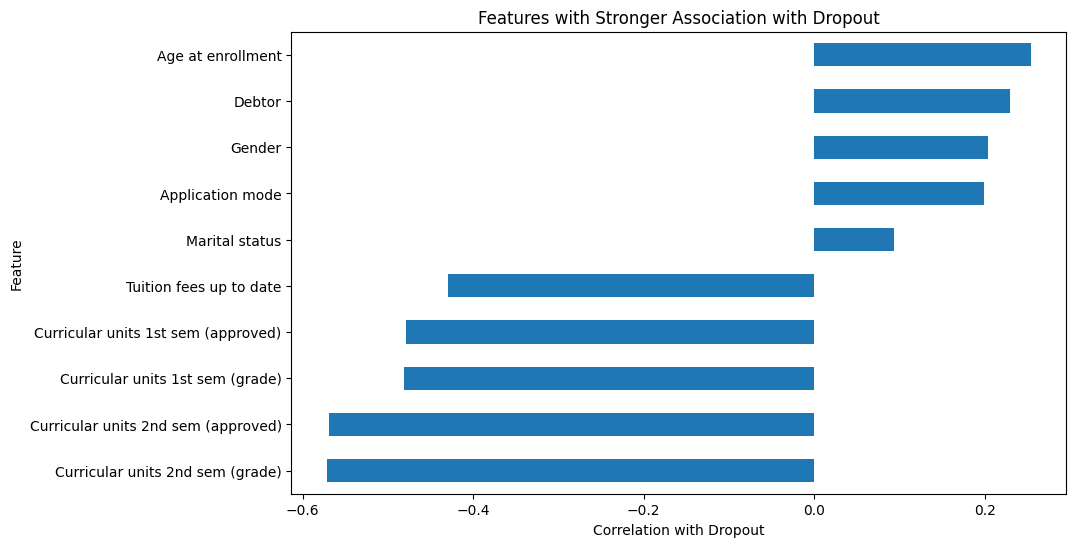

In [22]:
correlations_without_target = correlations.drop("Dropout")

top_positive = correlations_without_target.nlargest(5)
top_negative = correlations_without_target.nsmallest(5)

selected_correlations = pd.concat([
    top_negative,
    top_positive
])

plt.figure(figsize=(10,6))

selected_correlations.sort_values().plot(
    kind="barh"
)

plt.title("Features with Stronger Association with Dropout")
plt.xlabel("Correlation with Dropout")
plt.ylabel("Feature")

plt.show()

**Correlation Heatmao**

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


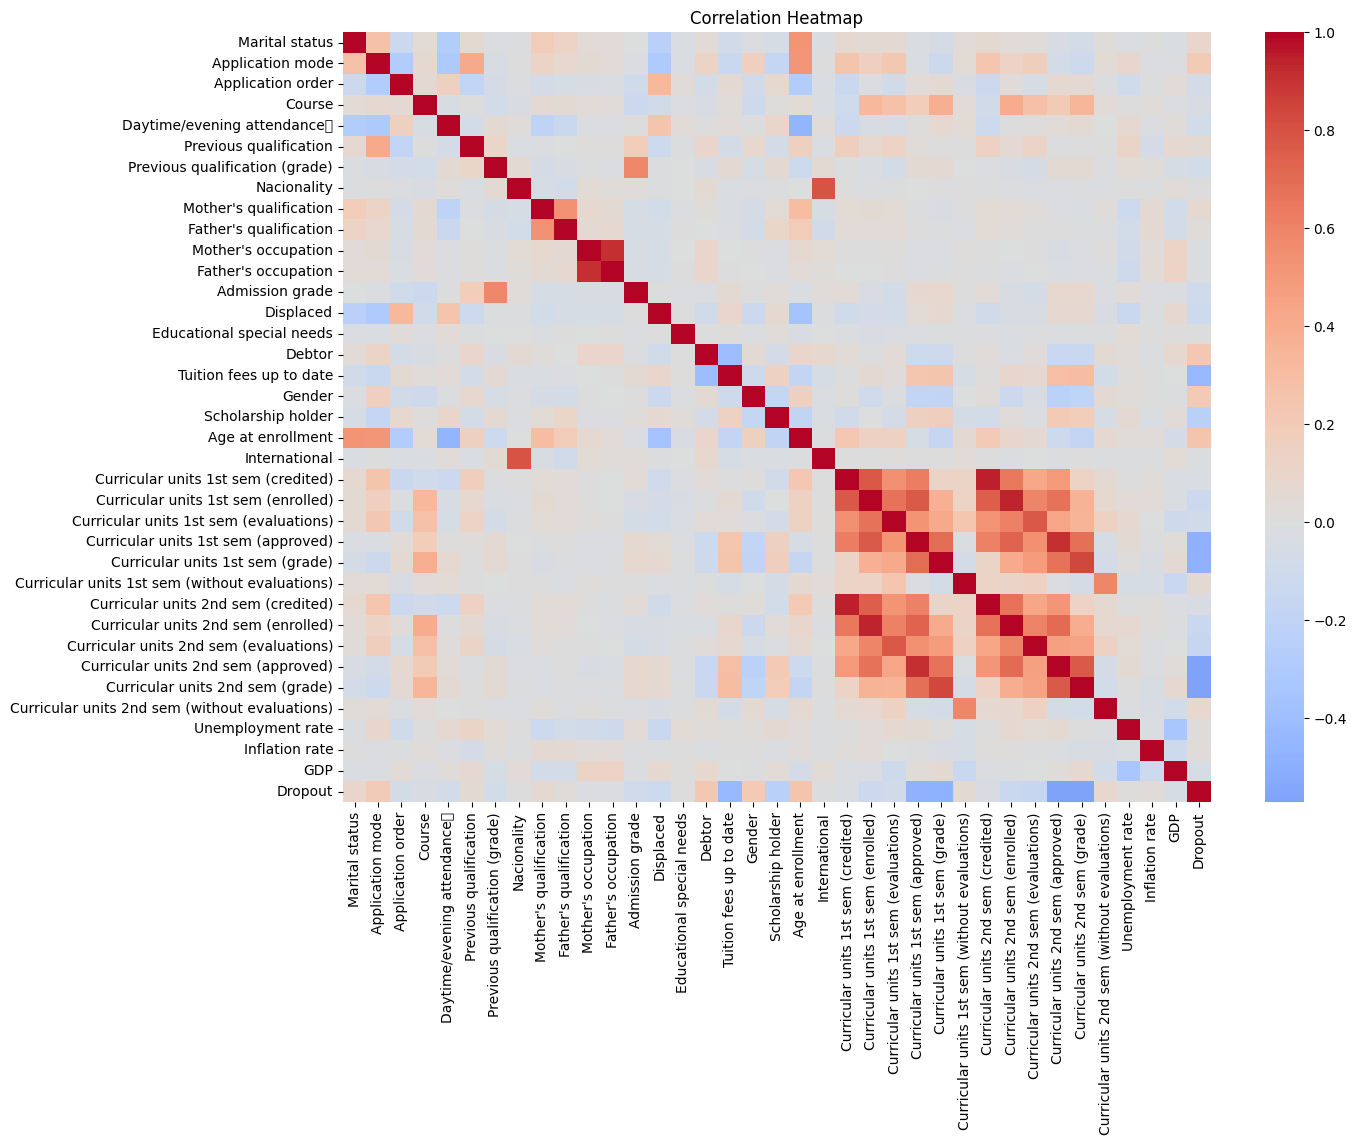

In [23]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

**Splitting the dataset**

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Dropout"])
y = df["Dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (3539, 36)
Testing Features: (885, 36)
Training Target: (3539,)
Testing Target: (885,)


**Training Logistic Regression**

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Making Predictions**

In [26]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0]


**Getting Prediction Probabilities**

In [27]:
y_probability = model.predict_proba(X_test_scaled)

print("Prediction Probabilities:")
print(y_probability[:10])

Prediction Probabilities:
[[0.97765291 0.02234709]
 [0.7483755  0.2516245 ]
 [0.02760728 0.97239272]
 [0.97685483 0.02314517]
 [0.0541236  0.9458764 ]
 [0.97154217 0.02845783]
 [0.05695216 0.94304784]
 [0.45788844 0.54211156]
 [0.94388738 0.05611262]
 [0.02102489 0.97897511]]


**Prediction Result**

In [28]:
import pandas as pd

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Not_Dropout": y_probability[:, 0],
    "Probability_Dropout": y_probability[:, 1]
})

display(prediction_results.head(10))

,Actual,Predicted,Probability_Not_Dropout,Probability_Dropout
0,0,0,0.977653,0.022347
1,0,0,0.748376,0.251624
2,1,1,0.027607,0.972393
3,0,0,0.976855,0.023145
4,1,1,0.054124,0.945876
5,0,0,0.971542,0.028458
6,1,1,0.056952,0.943048
7,1,1,0.457888,0.542112
8,0,0,0.943887,0.056113
9,1,1,0.021025,0.978975


**Importing evaluation metrics**

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

**Calculations**

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8858757062146893
Precision: 0.8893617021276595
Recall   : 0.7359154929577465
F1 Score : 0.8053949903660886


**Classification Report**

In [31]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Dropout", "Dropout"]
))

Classification Report:
              precision    recall  f1-score   support

 Not Dropout       0.88      0.96      0.92       601
     Dropout       0.89      0.74      0.81       284

    accuracy                           0.89       885
   macro avg       0.89      0.85      0.86       885
weighted avg       0.89      0.89      0.88       885



**Confusion Matrix**

In [32]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[575  26]
 [ 75 209]]


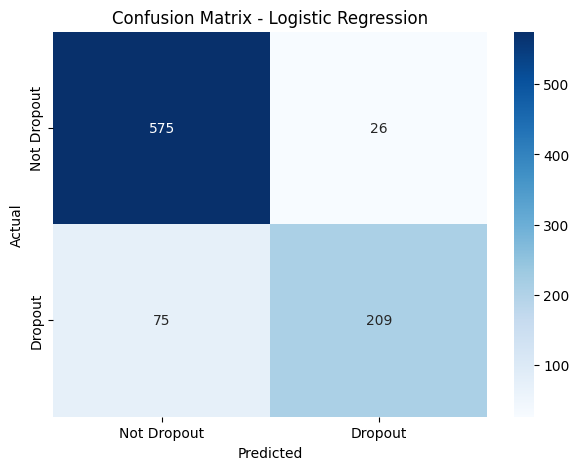

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Dropout", "Dropout"],
    yticklabels=["Not Dropout", "Dropout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**ROC - AUC**

In [34]:
roc_auc = roc_auc_score(
    y_test,
    y_probability[:, 1]
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9266070633451289


**Model Evaluation Results**

In [35]:
print("===== MODEL EVALUATION RESULTS =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

===== MODEL EVALUATION RESULTS =====
Accuracy : 0.8859
Precision: 0.8894
Recall   : 0.7359
F1 Score : 0.8054
ROC-AUC  : 0.9266


In [36]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(evaluation_results)

,Metric,Score
0,Accuracy,0.885876
1,Precision,0.889362
2,Recall,0.735915
3,F1 Score,0.805395
4,ROC-AUC,0.926607


**Error Analysis**

In [37]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

errors = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
]

print("Number of Incorrect Predictions:", len(errors))

display(errors.head(20))

Number of Incorrect Predictions: 101


,Actual,Predicted
28,0,1
30,1,0
32,1,0
36,1,0
38,1,0
44,1,0
59,0,1
62,0,1
67,1,0
74,1,0


**Testing a new student**

In [38]:
# Take one existing student as a test example
sample_student = X_test.iloc[[0]]

# Scale using the already trained scaler
sample_student_scaled = scaler.transform(sample_student)

# Predict class
prediction = model.predict(sample_student_scaled)[0]

# Predict probabilities
probabilities = model.predict_proba(sample_student_scaled)[0]

print("Predicted Class:", prediction)
print("Probability of Not Dropout:", probabilities[0])
print("Probability of Dropout:", probabilities[1])

Predicted Class: 0
Probability of Not Dropout: 0.977652909518297
Probability of Dropout: 0.022347090481703004


**Creating a Risk Level

In [40]:
def get_risk_level(dropout_probability):

    if dropout_probability < 0.30:
        return "Low Risk"

    elif dropout_probability < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [41]:
dropout_probability = probabilities[1]

risk_level = get_risk_level(dropout_probability)

print("Dropout Probability:", dropout_probability)
print("Risk Level:", risk_level)

Dropout Probability: 0.022347090481703004
Risk Level: Low Risk


In [42]:
!pip install gradio -q

In [48]:
import gradio as gr
import pandas as pd

# Exact feature order used by the trained model
feature_columns = X.columns.tolist()

# Categorical / coded features
categorical_columns = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance\t",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# Create choices directly from your dataset
choices = {}

for col in categorical_columns:
    values = df[col].dropna().unique().tolist()

    # Convert categorical values to strings
    choices[col] = sorted([str(int(v)) if float(v).is_integer() else str(v) for v in values])


# Prediction function
def predict_dropout(*values):

    # Create one-row DataFrame in EXACT same order as training data
    input_data = pd.DataFrame(
        [values],
        columns=feature_columns
    )

    # Make sure values are numeric
    input_data = input_data.astype(float)

    # Scale using the scaler fitted during training
    input_scaled = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(input_scaled)[0]

    # Probability
    probabilities = model.predict_proba(input_scaled)[0]
    dropout_probability = probabilities[1]

    # Risk category
    if dropout_probability < 0.30:
        risk = "Low Risk"
    elif dropout_probability < 0.60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    prediction_label = (
        "Dropout"
        if prediction == 1
        else "Not Dropout"
    )

    return (
        prediction_label,
        f"{dropout_probability:.2%}",
        risk
    )


# Function to load an example student from the testing data
def load_example(index):

    index = int(index)

    if index < 0 or index >= len(X_test):
        raise gr.Error(
            f"Please enter an index between 0 and {len(X_test)-1}."
        )

    student = X_test.iloc[index]

    values = []

    for col in feature_columns:

        value = student[col]

        if col in categorical_columns:
            # Convert categorical values to the same string format
            if float(value).is_integer():
                value = str(int(value))
            else:
                value = str(value)

        values.append(value)

    return values

# -----------------------------
# CREATE INTERFACE
# -----------------------------

with gr.Blocks(title="Student Dropout Risk Prediction") as demo:

    gr.Markdown(
        """
        # Student Dropout Risk Prediction

        Enter student information to predict dropout probability
        and risk level using a trained Logistic Regression model.
        """
    )

    gr.Markdown("### Student & Enrollment Information")

    inputs = []

    with gr.Row():
        with gr.Column():
            marital = gr.Dropdown(
                choices=choices["Marital status"],
                label="Marital Status"
            )
            application_mode = gr.Dropdown(
                choices=choices["Application mode"],
                label="Application Mode"
            )
            application_order = gr.Dropdown(
                choices=choices["Application order"],
                label="Application Order"
            )
            course = gr.Dropdown(
                choices=choices["Course"],
                label="Course"
            )
            attendance = gr.Dropdown(
                choices=choices["Daytime/evening attendance\t"],
                label="Daytime/Evening Attendance"
            )
            previous_qualification = gr.Dropdown(
                choices=choices["Previous qualification"],
                label="Previous Qualification"
            )

        with gr.Column():
            previous_grade = gr.Number(
                label="Previous Qualification Grade"
            )
            nationality = gr.Dropdown(
                choices=choices["Nacionality"],
                label="Nationality"
            )
            mother_qualification = gr.Dropdown(
                choices=choices["Mother's qualification"],
                label="Mother's Qualification"
            )
            father_qualification = gr.Dropdown(
                choices=choices["Father's qualification"],
                label="Father's Qualification"
            )
            mother_occupation = gr.Dropdown(
                choices=choices["Mother's occupation"],
                label="Mother's Occupation"
            )
            father_occupation = gr.Dropdown(
                choices=choices["Father's occupation"],
                label="Father's Occupation"
            )

    gr.Markdown("### Student Information")

    with gr.Row():
        with gr.Column():
            admission_grade = gr.Number(
                label="Admission Grade"
            )
            gender = gr.Dropdown(
                choices=choices["Gender"],
                label="Gender"
            )
            age = gr.Number(
                label="Age at Enrollment"
            )
            international = gr.Dropdown(
                choices=choices["International"],
                label="International"
            )

        with gr.Column():
            displaced = gr.Dropdown(
                choices=choices["Displaced"],
                label="Displaced"
            )
            special_needs = gr.Dropdown(
                choices=choices["Educational special needs"],
                label="Educational Special Needs"
            )
            debtor = gr.Dropdown(
                choices=choices["Debtor"],
                label="Debtor"
            )
            tuition = gr.Dropdown(
                choices=choices["Tuition fees up to date"],
                label="Tuition Fees Up to Date"
            )
            scholarship = gr.Dropdown(
                choices=choices["Scholarship holder"],
                label="Scholarship Holder"
            )

    gr.Markdown("### Academic Performance")

    with gr.Row():
        with gr.Column():
            sem1_credited = gr.Number(
                label="1st Sem - Credited Units"
            )
            sem1_enrolled = gr.Number(
                label="1st Sem - Enrolled Units"
            )
            sem1_evaluations = gr.Number(
                label="1st Sem - Evaluations"
            )
            sem1_approved = gr.Number(
                label="1st Sem - Approved Units"
            )
            sem1_grade = gr.Number(
                label="1st Sem - Grade"
            )
            sem1_without_eval = gr.Number(
                label="1st Sem - Without Evaluations"
            )

        with gr.Column():
            sem2_credited = gr.Number(
                label="2nd Sem - Credited Units"
            )
            sem2_enrolled = gr.Number(
                label="2nd Sem - Enrolled Units"
            )
            sem2_evaluations = gr.Number(
                label="2nd Sem - Evaluations"
            )
            sem2_approved = gr.Number(
                label="2nd Sem - Approved Units"
            )
            sem2_grade = gr.Number(
                label="2nd Sem - Grade"
            )
            sem2_without_eval = gr.Number(
                label="2nd Sem - Without Evaluations"
            )

    gr.Markdown("### Economic Indicators")

    with gr.Row():
        unemployment = gr.Number(
            label="Unemployment Rate"
        )
        inflation = gr.Number(
            label="Inflation Rate"
        )
        gdp = gr.Number(
            label="GDP"
        )

    # Put everything in EXACT column order
    inputs = [
        marital,
        application_mode,
        application_order,
        course,
        attendance,
        previous_qualification,
        previous_grade,
        nationality,
        mother_qualification,
        father_qualification,
        mother_occupation,
        father_occupation,
        admission_grade,
        displaced,
        special_needs,
        debtor,
        tuition,
        gender,
        scholarship,
        age,
        international,
        sem1_credited,
        sem1_enrolled,
        sem1_evaluations,
        sem1_approved,
        sem1_grade,
        sem1_without_eval,
        sem2_credited,
        sem2_enrolled,
        sem2_evaluations,
        sem2_approved,
        sem2_grade,
        sem2_without_eval,
        unemployment,
        inflation,
        gdp
    ]

    gr.Markdown("### Prediction")

    predict_button = gr.Button(
        "Predict Dropout Risk",
        variant="primary"
    )

    with gr.Row():
        predicted_class = gr.Textbox(
            label="Predicted Class"
        )
        dropout_probability = gr.Textbox(
            label="Dropout Probability"
        )
        risk_level = gr.Textbox(
            label="Risk Level"
        )

    predict_button.click(
        fn=predict_dropout,
        inputs=inputs,
        outputs=[
            predicted_class,
            dropout_probability,
            risk_level
        ]
    )

    gr.Markdown("### Testing with Existing Test Data")

    gr.Markdown(
        "You can load an unseen test-set student to demonstrate "
        "multiple test cases without manually entering all 36 values."
    )

    test_index = gr.Number(
        label="Test Student Index",
        value=0,
        precision=0
    )

    load_button = gr.Button("Load Test Student")

    load_button.click(
        fn=load_example,
        inputs=test_index,
        outputs=inputs
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aea96c4e7a50a459c8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [44]:
print(X.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
